In [118]:
import sys
print(sys.executable)
assert "AI-Ops" in sys.executable, "Select Python (AI-Ops) as the kernel."

/home/saiteja-ubuntu-31/my_project/AI-Ops/bin/python


In [119]:
import warnings
warnings.filterwarnings("ignore")

from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

SEED = 42
EPOCHS = 10
np.random.seed(SEED)

mlflow.set_tracking_uri("http://localhost:5000")

mlflow.autolog(disable=True)
mlflow.sklearn.autolog(disable=True)

print("Tracking URI:", mlflow.get_tracking_uri())
print("MLflow version:", mlflow.__version__)

Tracking URI: http://localhost:5000
MLflow version: 3.15.2


In [120]:
X, y = fetch_openml(
    "mnist_784",
    version=1,
    return_X_y=True,
    as_frame=False
)

X = X.astype(np.float32) / 255.0
y = y.astype(np.int64)

print("X:", X.shape)
print("y:", y.shape)

assert X.shape == (70000, 784)
assert y.shape == (70000,)

X: (70000, 784)
y: (70000,)


In [121]:
X_train_full, X_test = X[:60000], X[60000:]
y_train_full, y_test = y[:60000], y[60000:]

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=10000,
    random_state=SEED,
    stratify=y_train_full
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (50000, 784)
Validation: (10000, 784)
Test: (10000, 784)


In [122]:
experiments = [
    {"learning_rate": 0.0005, "batch_size": 64},
    {"learning_rate": 0.0005, "batch_size": 128},
    {"learning_rate": 0.0005, "batch_size": 256},

    {"learning_rate": 0.001, "batch_size": 64},
    {"learning_rate": 0.001, "batch_size": 128},
    {"learning_rate": 0.001, "batch_size": 256},
]

assert len(experiments) == 6
pd.DataFrame(experiments)

,learning_rate,batch_size
0,0.0005,64
1,0.0005,128
2,0.0005,256
3,0.0010,64
4,0.0010,128
5,0.0010,256


In [123]:
experiment_name = "mnist-mlp-q2-" + datetime.now().strftime("%Y%m%d-%H%M%S")
experiment_id = mlflow.create_experiment(experiment_name)

if mlflow.active_run() is not None:
    mlflow.end_run()

mlflow.autolog(disable=True)
mlflow.sklearn.autolog(disable=True)

results = []
history = []
expected_run_names = []

for run_number, config in enumerate(experiments, start=1):
    learning_rate = config["learning_rate"]
    batch_size = config["batch_size"]

    run_name = f"mlp-lr-{learning_rate}-bs-{batch_size}"
    expected_run_names.append(run_name)

    print()
    print("=" * 70)
    print(f"RUN {run_number}/6 | learning_rate={learning_rate} | batch_size={batch_size}")
    print("=" * 70)

    model = MLPClassifier(
        hidden_layer_sizes=(128,),
        activation="relu",
        solver="adam",
        learning_rate_init=learning_rate,
        batch_size=batch_size,
        random_state=SEED,
        max_iter=1
    )

    with mlflow.start_run(experiment_id=experiment_id, run_name=run_name):
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("hidden_layers", "(128,)")
        mlflow.log_param("activation", "relu")
        mlflow.log_param("optimizer", "adam")
        mlflow.log_param("epochs", EPOCHS)
        mlflow.log_param("seed", SEED)

        best_val_accuracy = 0.0
        best_epoch = 0

        for epoch in range(1, EPOCHS + 1):
            if epoch == 1:
                model.partial_fit(X_train, y_train, classes=np.arange(10))
            else:
                model.partial_fit(X_train, y_train)

            train_loss = float(model.loss_)
            val_pred = model.predict(X_val)
            val_accuracy = float(accuracy_score(y_val, val_pred))

            if val_accuracy > best_val_accuracy:
                best_val_accuracy = val_accuracy
                best_epoch = epoch

            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("val_accuracy", val_accuracy, step=epoch)

            history.append({
                "run_name": run_name,
                "learning_rate": learning_rate,
                "batch_size": batch_size,
                "epoch": epoch,
                "train_loss": train_loss,
                "val_accuracy": val_accuracy
            })

            print(
                f"Epoch {epoch}/{EPOCHS} | "
                f"train_loss={train_loss:.4f} | "
                f"val_accuracy={val_accuracy:.4f}"
            )

        test_pred = model.predict(X_test)
        test_accuracy = float(accuracy_score(y_test, test_pred))

        mlflow.log_metric("best_val_accuracy", best_val_accuracy)
        mlflow.log_metric("final_train_loss", train_loss)
        mlflow.log_metric("test_accuracy", test_accuracy)
        mlflow.log_metric("best_epoch", best_epoch)

        run_id = mlflow.active_run().info.run_id

        results.append({
            "run_number": run_number,
            "run_id": run_id,
            "run_name": run_name,
            "learning_rate": learning_rate,
            "batch_size": batch_size,
            "best_val_accuracy": best_val_accuracy,
            "best_epoch": best_epoch,
            "test_accuracy": test_accuracy,
            "final_train_loss": train_loss
        })
assert mlflow.active_run() is None

verification_df = mlflow.search_runs(experiment_ids=[experiment_id])

assert len(verification_df) == 6, (
    f"Expected exactly 6 runs, found {len(verification_df)}."
)

assert set(verification_df["status"]) == {"FINISHED"}

actual_names = set(verification_df["tags.mlflow.runName"])
assert actual_names == set(expected_run_names)

print()
print("=" * 70)
print("VERIFIED: EXACTLY SIX FINISHED MLFLOW RUNS")
print("Experiment:", experiment_name)
print("=" * 70)


RUN 1/6 | learning_rate=0.0005 | batch_size=64
Epoch 1/10 | train_loss=0.4190 | val_accuracy=0.9301
Epoch 2/10 | train_loss=0.2039 | val_accuracy=0.9480
Epoch 3/10 | train_loss=0.1531 | val_accuracy=0.9566
Epoch 4/10 | train_loss=0.1219 | val_accuracy=0.9621
Epoch 5/10 | train_loss=0.1005 | val_accuracy=0.9661
Epoch 6/10 | train_loss=0.0843 | val_accuracy=0.9683
Epoch 7/10 | train_loss=0.0718 | val_accuracy=0.9698
Epoch 8/10 | train_loss=0.0618 | val_accuracy=0.9708
Epoch 9/10 | train_loss=0.0534 | val_accuracy=0.9716
Epoch 10/10 | train_loss=0.0463 | val_accuracy=0.9724
🏃 View run mlp-lr-0.0005-bs-64 at: http://localhost:5000/#/experiments/16/runs/942dd84e95974209a03ff6b2643a93d0
🧪 View experiment at: http://localhost:5000/#/experiments/16

RUN 2/6 | learning_rate=0.0005 | batch_size=128
Epoch 1/10 | train_loss=0.5160 | val_accuracy=0.9234
Epoch 2/10 | train_loss=0.2396 | val_accuracy=0.9398
Epoch 3/10 | train_loss=0.1868 | val_accuracy=0.9491
Epoch 4/10 | train_loss=0.1538 | val_acc

In [124]:
results_df = pd.DataFrame(results)
results_sorted = results_df.sort_values(
    "best_val_accuracy",
    ascending=False
).reset_index(drop=True)
results_sorted

,run_number,run_id,run_name,learning_rate,batch_size,best_val_accuracy,best_epoch,test_accuracy,final_train_loss
0,4,96d22910e4fa45fa9b5b5a5958b64b45,mlp-lr-0.001-bs-64,0.0010,64,0.9734,10,0.9746,0.019894
1,5,0eaa6bdcc3114ffaaf302c9bf5586779,mlp-lr-0.001-bs-128,0.0010,128,0.9734,10,0.9740,0.034949
2,1,942dd84e95974209a03ff6b2643a93d0,mlp-lr-0.0005-bs-64,0.0005,64,0.9724,10,0.9738,0.046312
3,6,ac4ca6b7a045423b8a3be7d591eb603c,mlp-lr-0.001-bs-256,0.0010,256,0.9711,10,0.9701,0.056421
4,2,99d4848c23ce4d3e99739acb76c1e56d,mlp-lr-0.0005-bs-128,0.0005,128,0.9687,10,0.9697,0.068446
5,3,145199407c854dcb998855a29990dd83,mlp-lr-0.0005-bs-256,0.0005,256,0.9637,10,0.9640,0.100169


In [125]:
runs_df = mlflow.search_runs(
    experiment_ids=[experiment_id],
    order_by=["metrics.best_val_accuracy DESC"]
)

display_cols = [
    "run_id",
    "tags.mlflow.runName",
    "status",
    "params.learning_rate",
    "params.batch_size",
    "metrics.best_val_accuracy",
    "metrics.test_accuracy",
    "metrics.final_train_loss",
    "metrics.best_epoch",
]

runs_df[display_cols]

,run_id,tags.mlflow.runName,status,params.learning_rate,params.batch_size,metrics.best_val_accuracy,metrics.test_accuracy,metrics.final_train_loss,metrics.best_epoch
0,0eaa6bdcc3114ffaaf302c9bf5586779,mlp-lr-0.001-bs-128,FINISHED,0.001,128,0.9734,0.9740,0.034949,10.0
1,96d22910e4fa45fa9b5b5a5958b64b45,mlp-lr-0.001-bs-64,FINISHED,0.001,64,0.9734,0.9746,0.019894,10.0
2,942dd84e95974209a03ff6b2643a93d0,mlp-lr-0.0005-bs-64,FINISHED,0.0005,64,0.9724,0.9738,0.046312,10.0
3,ac4ca6b7a045423b8a3be7d591eb603c,mlp-lr-0.001-bs-256,FINISHED,0.001,256,0.9711,0.9701,0.056421,10.0
4,99d4848c23ce4d3e99739acb76c1e56d,mlp-lr-0.0005-bs-128,FINISHED,0.0005,128,0.9687,0.9697,0.068446,10.0
5,145199407c854dcb998855a29990dd83,mlp-lr-0.0005-bs-256,FINISHED,0.0005,256,0.9637,0.9640,0.100169,10.0


In [126]:
best_run = runs_df.iloc[0]

print("Run ID:", best_run["run_id"])
print("Run name:", best_run["tags.mlflow.runName"])
print("Learning rate:", best_run["params.learning_rate"])
print("Batch size:", best_run["params.batch_size"])
print("Best validation accuracy:", best_run["metrics.best_val_accuracy"])
print("Test accuracy:", best_run["metrics.test_accuracy"])

Run ID: 0eaa6bdcc3114ffaaf302c9bf5586779
Run name: mlp-lr-0.001-bs-128
Learning rate: 0.001
Batch size: 128
Best validation accuracy: 0.9734
Test accuracy: 0.974


In [127]:
history_df = pd.DataFrame(history)
history_df

,run_name,learning_rate,batch_size,epoch,train_loss,val_accuracy
0,mlp-lr-0.0005-bs-64,0.0005,64,1,0.419037,0.9301
1,mlp-lr-0.0005-bs-64,0.0005,64,2,0.203892,0.9480
2,mlp-lr-0.0005-bs-64,0.0005,64,3,0.153073,0.9566
3,mlp-lr-0.0005-bs-64,0.0005,64,4,0.121945,0.9621
4,mlp-lr-0.0005-bs-64,0.0005,64,5,0.100459,0.9661
5,mlp-lr-0.0005-bs-64,0.0005,64,6,0.084339,0.9683
6,mlp-lr-0.0005-bs-64,0.0005,64,7,0.071839,0.9698
7,mlp-lr-0.0005-bs-64,0.0005,64,8,0.061753,0.9708
8,mlp-lr-0.0005-bs-64,0.0005,64,9,0.053422,0.9716
9,mlp-lr-0.0005-bs-64,0.0005,64,10,0.046312,0.9724


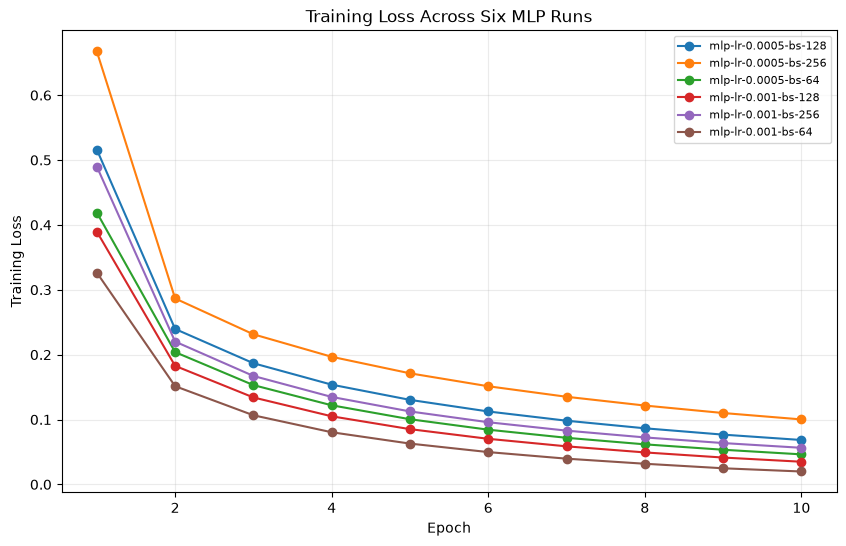

In [128]:
plt.figure(figsize=(10, 6))
for run_name, group in history_df.groupby("run_name"):
    plt.plot(group["epoch"], group["train_loss"], marker="o", label=run_name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Across Six MLP Runs")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.25)
plt.show()

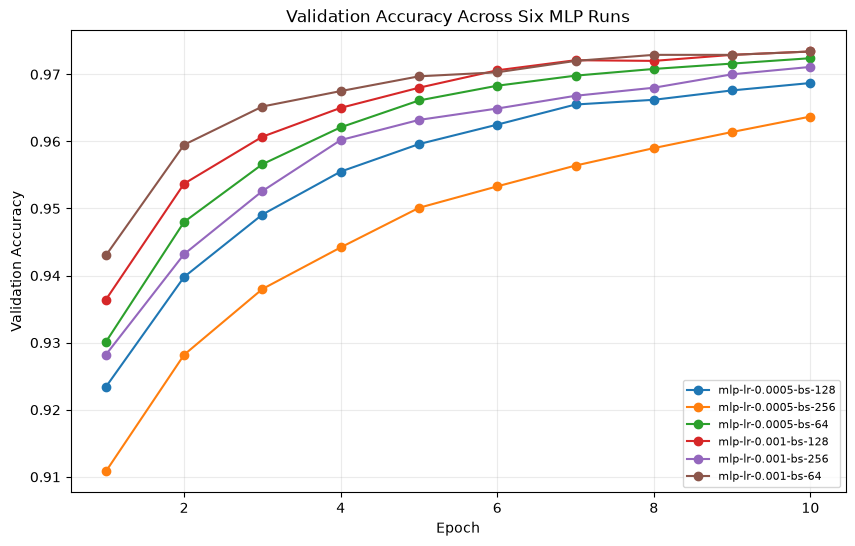

In [129]:
plt.figure(figsize=(10, 6))
for run_name, group in history_df.groupby("run_name"):
    plt.plot(group["epoch"], group["val_accuracy"], marker="o", label=run_name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across Six MLP Runs")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.25)
plt.show()

In [130]:
lr_summary = results_df.groupby("learning_rate")["best_val_accuracy"].mean().sort_index()
batch_summary = results_df.groupby("batch_size")["best_val_accuracy"].mean().sort_index()

learning_rate_effect = float(lr_summary.max() - lr_summary.min())
batch_size_effect = float(batch_summary.max() - batch_summary.min())

print("Mean best validation accuracy by learning rate:")
print(lr_summary)
print()
print("Mean best validation accuracy by batch size:")
print(batch_summary)
print()
print("Learning-rate effect:", learning_rate_effect)
print("Batch-size effect:", batch_size_effect)

if learning_rate_effect > batch_size_effect:
    print("Larger observed effect: learning rate")
elif batch_size_effect > learning_rate_effect:
    print("Larger observed effect: batch size")
else:
    print("Observed effects are equal by this comparison.")

Mean best validation accuracy by learning rate:
learning_rate
0.0005    0.968267
0.0010    0.972633
Name: best_val_accuracy, dtype: float64

Mean best validation accuracy by batch size:
batch_size
64     0.97290
128    0.97105
256    0.96740
Name: best_val_accuracy, dtype: float64

Learning-rate effect: 0.004366666666666741
Batch-size effect: 0.00550000000000006
Larger observed effect: batch size
